In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [7]:
df= pd.read_csv("tweet_replies2.csv")

In [8]:
df.head()

,User,Text,Date
0,@BarisUnver,700 bin lira bütçeye uygun en dertsiz aile ara...,2025-12-26T06:33:05.000Z
1,@anumariiii,Aga her modele bi cevabın var ama nedense diy...,2025-12-26T20:53:14.000Z
2,@BarisUnver,"Vallahi anlamıyorum ya, verdiğin cevaplarda bi...",2025-12-26T21:10:03.000Z
3,@turistikoda,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.,2025-12-26T20:57:29.000Z
4,@BarisUnver,"Allah sana daha çok versin, yapacak bir şey yo...",2025-12-26T21:12:59.000Z


In [9]:
df.tail()

,User,Text,Date
345,@urulusoy_ugur,Mitsubishi kanser 1.6 köpek balığı,2025-12-26T22:49:04.000Z
346,@gelecekicinuret,El arabası yada at arabası,2025-12-26T20:40:01.000Z
347,@ergunkrt,Edirne'den çıkınca bunları alabilirsiniz.,2025-12-26T23:23:19.000Z
348,@iamyourfather89,Pejo 301 ve Citroen c elysee 1.6 hdi veya 1.6 ...,2025-12-26T21:58:09.000Z
349,@mit57730385,Toyota Corolla,2025-12-26T22:38:29.000Z


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   User    350 non-null    object
 1   Text    350 non-null    object
 2   Date    350 non-null    object
dtypes: object(3)
memory usage: 8.3+ KB


In [11]:
df.isna().sum()

User    0
Text    0
Date    0
dtype: int64

In [12]:
df = df.drop("Date", axis = 1)

In [13]:
df.head()

,User,Text
0,@BarisUnver,700 bin lira bütçeye uygun en dertsiz aile ara...
1,@anumariiii,Aga her modele bi cevabın var ama nedense diy...
2,@BarisUnver,"Vallahi anlamıyorum ya, verdiğin cevaplarda bi..."
3,@turistikoda,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.
4,@BarisUnver,"Allah sana daha çok versin, yapacak bir şey yo..."


In [14]:
i = df[df.User == "@BarisUnver"].index
df.drop(i, inplace = True)

In [15]:
df.drop("User", axis = 1, inplace = True)

In [16]:
df

,Text
1,Aga her modele bi cevabın var ama nedense diy...
3,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.
5,Hyundai i20 birde tüplü oldu mu dadından yenm...
6,Clio
7,O paralara araba var mı ya
...,...
345,Mitsubishi kanser 1.6 köpek balığı
346,El arabası yada at arabası
347,Edirne'den çıkınca bunları alabilirsiniz.
348,Pejo 301 ve Citroen c elysee 1.6 hdi veya 1.6 ...


In [17]:
df.head()

,Text
1,Aga her modele bi cevabın var ama nedense diy...
3,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.
5,Hyundai i20 birde tüplü oldu mu dadından yenm...
6,Clio
7,O paralara araba var mı ya


In [18]:
df

,Text
1,Aga her modele bi cevabın var ama nedense diy...
3,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.
5,Hyundai i20 birde tüplü oldu mu dadından yenm...
6,Clio
7,O paralara araba var mı ya
...,...
345,Mitsubishi kanser 1.6 köpek balığı
346,El arabası yada at arabası
347,Edirne'den çıkınca bunları alabilirsiniz.
348,Pejo 301 ve Citroen c elysee 1.6 hdi veya 1.6 ...


In [19]:
from nltk.tokenize import word_tokenize

In [20]:
# text tokenize işlemi (cümleyi kelimelere ayırarak liste oluşturur)
word_tokenize(df.loc[15,"Text"])

['Toyota',
 ',',
 'Honda',
 've',
 'Hyundainin',
 '700',
 'bin',
 'TL',
 'ye',
 'satılan',
 'tüm',
 'modelleri',
 '!',
 'Bu',
 'markalarda',
 'yaş',
 've',
 'km',
 'nin',
 'hiçbir',
 'önemi',
 'yok.yeterki',
 'bakımları',
 'zamanında',
 'yapılmış',
 'olsun',
 '.']

In [21]:
from nltk.corpus import stopwords
nltk.download("stopwords")
stopWords = set(stopwords.words("turkish"))

[nltk_data] Downloading package stopwords to C:\Users\hp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
stopWords

{'acaba',
 'ama',
 'aslında',
 'az',
 'bazı',
 'belki',
 'biri',
 'birkaç',
 'birşey',
 'biz',
 'bu',
 'da',
 'daha',
 'de',
 'defa',
 'diye',
 'en',
 'eğer',
 'gibi',
 'hem',
 'hep',
 'hepsi',
 'her',
 'hiç',
 'ile',
 'ise',
 'için',
 'kez',
 'ki',
 'kim',
 'mu',
 'mü',
 'mı',
 'nasıl',
 'ne',
 'neden',
 'nerde',
 'nerede',
 'nereye',
 'niye',
 'niçin',
 'o',
 'sanki',
 'siz',
 'tüm',
 've',
 'veya',
 'ya',
 'yani',
 'çok',
 'çünkü',
 'şey',
 'şu'}

#tokenization

In [23]:
df["Tokenized"] = df["Text"].str.lower().apply(word_tokenize)

In [24]:
df.head()

,Text,Tokenized
1,Aga her modele bi cevabın var ama nedense diy...,"[aga, her, modele, bi, cevabın, var, ama, nede..."
3,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.,"[ne, fakirsin, 700, ü, ben, bazen, ayda, kazan..."
5,Hyundai i20 birde tüplü oldu mu dadından yenm...,"[hyundai, i20, birde, tüplü, oldu, mu, dadında..."
6,Clio,[clio]
7,O paralara araba var mı ya,"[o, paralara, araba, var, mı, ya]"


In [25]:
df["FilteredText"] = df["Text"].apply(lambda text: " ".join([word for word in str(text).split() if word not in stopWords and word.isalpha()]))

In [26]:
df.head()

,Text,Tokenized,FilteredText
1,Aga her modele bi cevabın var ama nedense diy...,"[aga, her, modele, bi, cevabın, var, ama, nede...",Aga modele bi cevabın var nedense diyorsun anl...
3,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.,"[ne, fakirsin, 700, ü, ben, bazen, ayda, kazan...",Ne fakirsin ü ben bazen ayda
5,Hyundai i20 birde tüplü oldu mu dadından yenm...,"[hyundai, i20, birde, tüplü, oldu, mu, dadında...",Hyundai birde tüplü oldu dadından yenmez trige...
6,Clio,[clio],Clio
7,O paralara araba var mı ya,"[o, paralara, araba, var, mı, ya]",O paralara araba var


In [27]:
df.drop("Class", axis = 1 , inplace = True)

KeyError: "['Class'] not found in axis"

In [36]:
df.insert(3,"Class",-1)

In [ ]:
df

In [ ]:
!pip install transformers

In [ ]:
!pip install torch transformers

In [34]:
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import torch

In [ ]:
MODEL_NAME = "dbmdz/bert-base-turkish-cased"

In [ ]:
print("Model ve Tokenizer yükleniyor... (İlk seferde biraz sürebilir)")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

In [ ]:
!pip install huggingface_hub

In [31]:
def get_bert_embeddings(text):
    # 1. Tokenize et (Modelin anlayacağı sayısal id'lere çevir)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
    # 2. Modelden geçir (Gradient hesaplamaya gerek yok, sadece çıktı alıyoruz)
    with torch.no_grad():
        outputs = model(**inputs)

    cls_embedding = outputs.last_hidden_state[0, 0, :].numpy()
    
    return cls_embedding

In [35]:
print("Vektörler oluşturuluyor... (350 satır için işlemci ile kısa sürer)")

# Her satır için fonksiyonu çalıştırıp listeye atıyoruz
# Not: Veri setin küçük olduğu için 'apply' kullanmak sorun yaratmaz.
df['vector'] = df['Text'].apply(lambda x: get_bert_embeddings(str(x)))

Vektörler oluşturuluyor... (350 satır için işlemci ile kısa sürer)


In [43]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

matrix = np.array([get_bert_embeddings(text) for text in df['FilteredText']])

# --- 4. K-MEANS KÜMELEME ---
print("2/3 Kümeleme yapılıyor...")
# n_clusters=2 diyoruz (Pozitif ve Negatif olarak ayırmasını umuyoruz)
kMeans = KMeans(n_clusters=2, random_state=42)
kMeans.fit(matrix)

# Etiketleri DataFrame'e ekleyelim (0 veya 1 atayacak)
df['class2'] = kMeans.labels_

2/3 Kümeleme yapılıyor...


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [ ]:
X = np.array(df['vector'].tolist())
y = df['Class'].values # Etiket sütununun adı neyse onu yaz (örn: 'sentiment', 'label')

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM Modeli Tanımlama ve Eğitme
svm_model = SVC(kernel='linear') # 'linear' veya 'rbf' denenebilir
svm_model.fit(X_train, y_train)

In [46]:
df.drop("Class", axis = 1, inplace=True)

In [47]:
df

,Text,Tokenized,FilteredText,vector,class,class2
1,Aga her modele bi cevabın var ama nedense diy...,"[aga, her, modele, bi, cevabın, var, ama, nede...",Aga modele bi cevabın var nedense diyorsun anl...,"[0.8454037, -0.36093083, -0.12229962, 0.215683...",1,0
3,Ne fakirsin 700 ü ben bazen ayda kazanıyorum.,"[ne, fakirsin, 700, ü, ben, bazen, ayda, kazan...",Ne fakirsin ü ben bazen ayda,"[0.33879542, 0.51132166, 0.3427785, -0.3261304...",0,0
5,Hyundai i20 birde tüplü oldu mu dadından yenm...,"[hyundai, i20, birde, tüplü, oldu, mu, dadında...",Hyundai birde tüplü oldu dadından yenmez trige...,"[0.6433203, -0.26200956, 0.06684129, 0.1672470...",1,0
6,Clio,[clio],Clio,"[0.033433642, 1.095575, 0.4486351, -0.35448787...",0,0
7,O paralara araba var mı ya,"[o, paralara, araba, var, mı, ya]",O paralara araba var,"[-0.41628748, 1.4779333, 0.11391975, 0.0392383...",0,0
...,...,...,...,...,...,...
345,Mitsubishi kanser 1.6 köpek balığı,"[mitsubishi, kanser, 1.6, köpek, balığı]",Mitsubishi kanser köpek balığı,"[-0.19462219, 1.3161503, 0.28500426, -0.209501...",0,0
346,El arabası yada at arabası,"[el, arabası, yada, at, arabası]",El arabası yada at arabası,"[-0.41917393, 1.1793894, 0.3289504, -0.1071636...",0,0
347,Edirne'den çıkınca bunları alabilirsiniz.,"[edirne'den, çıkınca, bunları, alabilirsiniz, .]",çıkınca bunları,"[-0.15297061, 1.3894682, 0.43758655, 0.5520352...",0,0
348,Pejo 301 ve Citroen c elysee 1.6 hdi veya 1.6 ...,"[pejo, 301, ve, citroen, c, elysee, 1.6, hdi, ...",Pejo Citroen c elysee hdi litre bagaj km şehir...,"[0.9325169, -0.064688936, 0.17833467, 0.009136...",1,1


3/3 Grafik çiziliyor...


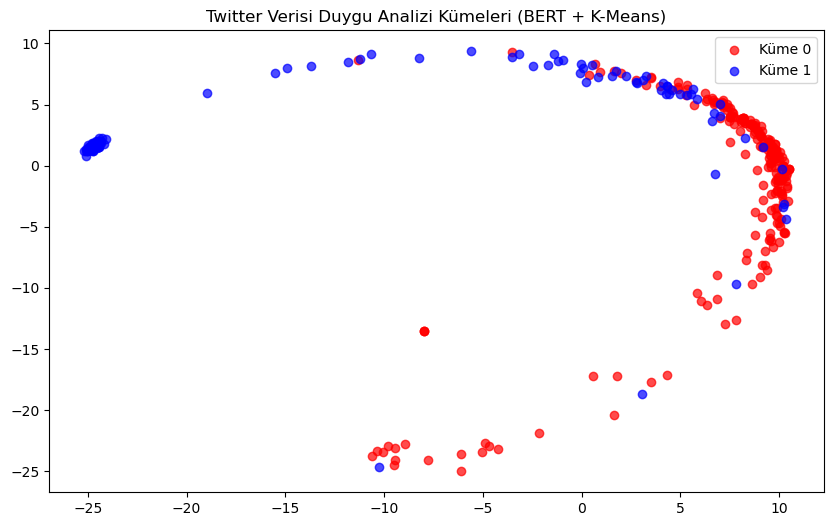

In [48]:
print("3/3 Grafik çiziliyor...")
# 768 boyutu 2 boyuta indiriyoruz ki grafikte görebilelim
pca = PCA(n_components=2)
reduced_matrix = pca.fit_transform(matrix)

plt.figure(figsize=(10, 6))
colors = ['red', 'blue']

for i in range(2):
    # Her kümeyi farklı renkte çiz
    points = reduced_matrix[df['class'] == i]
    plt.scatter(points[:, 0], points[:, 1], c=colors[i], label=f'Küme {i}', alpha=0.7)

plt.title("Twitter Verisi Duygu Analizi Kümeleri (BERT + K-Means)")
plt.legend()
plt.show()